# Wan TI2V Causal Window and SSM Memory

This notebook uses the `new` conda environment/kernel. The shared local attention is causal and frame-blocked: query tokens in latent frame `f` attend to frames `[f-l, ..., f]` with temporal RoPE applied relative to that local window. Training uses standard Wan flow matching: frame 0 is kept clean as the input/mask frame, future latent frames are noised with sigmas from the Wan UniPC scheduler, and the model predicts velocity (`noise - clean`) with timestep AdaLN conditioning enabled. The clean first latent frame is also provided through the per-block AdaLN0 first-frame conditioner; text conditioning remains disabled. Evaluation samples with the Wan `FlowUniPCMultistepScheduler` for `EVAL_INFERENCE_STEPS=20`. It filters the dataset by safetensor latent-frame count and progressively truncates batches up to `LATENT_FRAME_COUNT` inside the training path. The current stacked-vorticity videos are 256x256 images, which Wan TI2V VAE stores as 16x16 spatial latents.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "navier":
    NOTEBOOK_DIR = Path("/home/azureuser/physics/navier")
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import autoreg_windowed_lora as awl

print(sys.executable)
print("device:", awl.DEVICE)

/opt/miniforge/envs/new/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/opt/miniforge/envs/new/bin/python
device: cuda


In [ ]:
import torch

CONFIG = dict(
    LATENT_ROOT=Path("/home/azureuser/datasets/navier_with_vorticity"),
    WAN_REPO_ROOT=Path("/home/azureuser/physics/navier/Wan2.2"),
    WAN_CHECKPOINT_DIR=Path("/home/azureuser/Wan2.2-TI2V-5B"),
    OUTPUT_DIR=Path("/home/azureuser/physics/navier/autoreg_lora_outputs"),
    DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    PARAM_DTYPE=torch.bfloat16,
    TRAIN_DTYPE=torch.bfloat16,
    BATCH_SIZE=2,
    GRAD_ACCUM_STEPS=2,
    LEARNING_RATE=1e-4,
    LR_WARMUP_STEPS=1,
    MAX_STEPS=30000,
    CLIP_GRAD_NORM=1.0,
    LOSS_EMA_BETA=0.99,
    TRANSFORMER_DROPPED_LAYERS=(
        # 4, 5,
        # 6, 7, 
        # 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 
        # 24, 25, 26
    ),
    TRAIN_RANDOM_LAYER_DROP=False,
    GRADIENT_CHECKPOINT_DISABLE_BLOCKS="all",
    TRAIN_INIT_LOGS=True,
    REGIONAL_COMPILE=False,
    REGIONAL_COMPILE_BACKEND="inductor",
    REGIONAL_COMPILE_MODE="reduce-overhead",
    REGIONAL_COMPILE_FULLGRAPH=False,
    REGIONAL_COMPILE_DYNAMIC=False,
    REGIONAL_COMPILE_CAPTURE_SCALAR_OUTPUTS=True,
    USE_FLEX_ATTENTION=True,
    FLEX_ATTENTION_BLOCK_SIZE=128,
    FLEX_ATTENTION_DYNAMIC=True,
    FLEX_ATTENTION_RECOMPILE_LIMIT=64,
    FIRST_FRAME_CONDITIONING_DIM=32,
    WAN_NUM_TRAIN_TIMESTEPS=1000,
    WAN_SAMPLE_SHIFT=5.0,
    EVAL_INFERENCE_STEPS=20,
    WINDOW_LEFT_FRAMES=3,
    WINDOW_RIGHT_FRAMES=0,
    MIN_LATENT_FRAME_COUNT=12,
    LATENT_FRAME_COUNT=40,
    PROGRESSIVE_SEQUENCE_LENGTH_START=6,
    PROGRESSIVE_SEQUENCE_LENGTH_STEP_INTERVAL=200,
    HOLDOUT_COUNT=100,
    EVAL_EVERY=500,
    EVAL_FPS=32,
    EVAL_ERROR_VMAX=0.45,
    # Stacked-vorticity videos are 256x256; Wan TI2V VAE spatial stride is 16, so latents are 16x16.
    VIDEO_OUTPUT_SIZE=256,
    SAVE_EVERY=None,
    LORA_R=16,
    LORA_ALPHA=16,
    LORA_DROPOUT=0.0,
    LORA_TARGET_MODULES=[
        "self_attn.q",
        "self_attn.k",
        "self_attn.v",
        "self_attn.o",
        "ffn.0",
        "ffn.2",
    ],
    PATCH_EMBEDDING_LORA_R=16,
    PATCH_EMBEDDING_LORA_ALPHA=16,
    TIMESTEP_ADALN_LORA_R=16,
    TIMESTEP_ADALN_LORA_ALPHA=16,
    SSM_DECAY_INIT=0.9,
    SSM_INPUT_INIT=1e-1,
    SSM_OUTPUT_INIT=1.0,
    SSM_SKIP_INIT=0.0,
    SSM_RHO_INIT=1e-2,
    SSM_FREEZE_RHO_ZERO=False,
    SSM_QUERY_SCALE=None,
    SSM_LAYER_COUNT=4,
    SSM_RECURRENT_DIM=512,
    SSM_STATE_MIXER_EXPANSION=1,
    SSM_USE_CONVOLUTIONS=False,
    REQUIRE_RHO=True,
    RANDOM_SEED=1234,
)

awl.configure(**CONFIG)
for key, value in awl.get_config().items():
    print(f"{key}: {value}")

LATENT_ROOT: /home/azureuser/datasets/navier_with_vorticity
WAN_REPO_ROOT: /home/azureuser/physics/navier/Wan2.2
WAN_CHECKPOINT_DIR: /home/azureuser/Wan2.2-TI2V-5B
OUTPUT_DIR: /home/azureuser/physics/navier/autoreg_lora_outputs
DEVICE: cuda
PARAM_DTYPE: torch.bfloat16
TRAIN_DTYPE: torch.bfloat16
BATCH_SIZE: 2
GRAD_ACCUM_STEPS: 2
LEARNING_RATE: 0.0001
LR_WARMUP_STEPS: 1
MAX_STEPS: 30000
CLIP_GRAD_NORM: 1.0
LOSS_EMA_BETA: 0.99
TRANSFORMER_DROPPED_LAYERS: (4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26)
TRAIN_RANDOM_LAYER_DROP: False
GRADIENT_CHECKPOINT_DISABLE_BLOCKS: all
TRAIN_INIT_LOGS: True
REGIONAL_COMPILE: False
REGIONAL_COMPILE_BACKEND: inductor
REGIONAL_COMPILE_MODE: reduce-overhead
REGIONAL_COMPILE_FULLGRAPH: False
REGIONAL_COMPILE_DYNAMIC: False
REGIONAL_COMPILE_CAPTURE_SCALAR_OUTPUTS: True
USE_FLEX_ATTENTION: True
FLEX_ATTENTION_BLOCK_SIZE: 128
FLEX_ATTENTION_DYNAMIC: True
FLEX_ATTENTION_RECOMPILE_LIMIT: 64
FIRST_FRAME_CONDITIONING_DIM: 32


In [3]:
import torch

grid = torch.tensor([[4, 2, 3]])
mask = awl.frame_window_mask(grid, seq_len=24, left_frames=1, right_frames=0)[0]
assert torch.where(mask[0])[0].tolist() == list(range(6))
assert torch.where(mask[12])[0].tolist() == list(range(6, 18))
assert torch.where(mask[18])[0].tolist() == list(range(12, 24))
print("mask ok: causal left window without first-frame anchor")


mask ok: causal left window without first-frame anchor


In [4]:
samples = awl.discover_latent_samples()
train_samples, holdout_samples = awl.make_splits(samples)
print(f"latents: {len(samples):,}")
print(f"train: {len(train_samples):,}")
print(f"holdout: {len(holdout_samples):,}")
print("example:", samples[0].latents_path)


[sample discovery] checking 2,000 latent files in /home/azureuser/datasets/navier_with_vorticity (min latent frames=12)
[sample discovery] checked 500/2,000; kept 500; elapsed 0.0s
[sample discovery] checked 1,000/2,000; kept 1,000; elapsed 0.1s
[sample discovery] checked 1,500/2,000; kept 1,500; elapsed 0.1s


[sample discovery] done in 0.2s; kept 2,000; skipped_short=0; skipped_bad_latents=0; skipped_metadata=0
latents: 2,000
train: 1,900
holdout: 100
example: /home/azureuser/datasets/navier_with_vorticity/0012232107d82029/latents.safetensors


[train init] train_ssm_window(flow_matching, max_steps=30000) starting
[train init] build SSM window objects ...
[train init] mode=flow_matching device=cuda param_dtype=torch.bfloat16 train_dtype=torch.bfloat16
[train init] Wan scheduler flow matching: clean frame 0, noisy future frames, shift=5, eval_steps=20
[train init] discover latent samples ...
[sample discovery] checking 2,000 latent files in /home/azureuser/datasets/navier_with_vorticity (min latent frames=12)
[sample discovery] checked 500/2,000; kept 500; elapsed 0.0s
[sample discovery] checked 1,000/2,000; kept 1,000; elapsed 0.1s
[sample discovery] checked 1,500/2,000; kept 1,500; elapsed 0.1s


[sample discovery] done in 0.2s; kept 2,000; skipped_short=0; skipped_bad_latents=0; skipped_metadata=0
[train init] discover latent samples done in 0.2s
[train init] found 2,000 samples in /home/azureuser/datasets/navier_with_vorticity
[train init] split dataset and compute physics stats ...
[train init] split dataset and compute physics stats done in 0.0s
[train init] train=1,900 holdout=100
[train init] text conditioning disabled; timestep AdaLN conditioning enabled
[train init] create latent dataset and dataloader ...
[train init] create latent dataset and dataloader done in 0.0s
[train init] load student Wan transformer from /home/azureuser/Wan2.2-TI2V-5B ...


Loading checkpoint shards: 100%|██████████| 3/3 [00:00<00:00,  3.22it/s]


[train init] load student Wan transformer from /home/azureuser/Wan2.2-TI2V-5B done in 1.7s
[train init] attach student physics conditioning and SSM memory ...
[train init] attach student physics conditioning and SSM memory done in 0.2s
[train init] attach student LoRA adapters ...
[train init] attach student LoRA adapters done in 0.3s
[train init] configure student gradient checkpointing ...
gradient checkpointing enabled on 0/30 blocks; disabled blocks: all
[train init] configure student gradient checkpointing done in 0.0s
[train init] enable SSM/windowed student training ...
[train init] enable SSM/windowed student training done in 0.0s
[train init] regionally compile student repeated Wan blocks ...
[train init] regionally compile student repeated Wan blocks done in 0.0s
[train init] create optimizer ...
[train init] create optimizer done in 0.0s
SSM window trainable params: 38,360,964 / 5,052,140,772 (init=pretrained, ssm=22,108,164, lora=6,651,904, patch_lora=52,224, timestep_lora=

ssm-window:   0%|          | 0/30000 [00:00<?, ?it/s]

...

[train init] active latent frame count at step 201: 7


ssm-window:   1%|▏         | 400/30000 [01:35<1:54:01,  4.33it/s, mse_ema=0.139647, seq=7, total_ema=0.139647]

[train init] active latent frame count at step 401: 8


ssm-window:   2%|▏         | 499/30000 [02:00<2:03:22,  3.99it/s, mse_ema=0.114992, seq=8, total_ema=0.114992]

step 500: 8a55df4b7f80f131 | nu=2.31e-03, rho=1.3 | left=ssm Wan flow 20 steps causal window L=3 | middle=ground truth | right=absolute error
pred_latents: min=-5.000, max=5.656, mean=-0.149, std=1.458 | gt_latents: min=-4.945, max=5.488, mean=-0.153, std=1.472 | pred_video: min=-1.000, max=1.000, mean=0.255, std=0.535 | gt_video: min=-1.000, max=1.000, mean=0.268, std=0.533


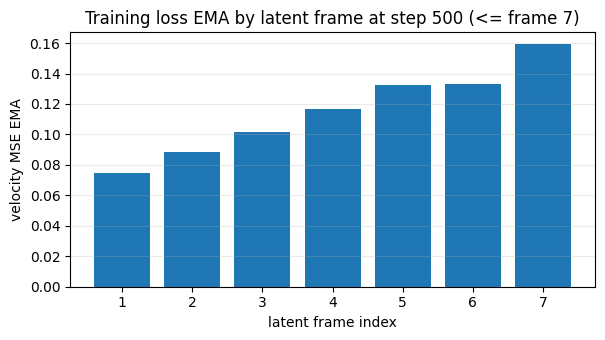

ssm-window:   2%|▏         | 522/30000 [02:08<2:00:41,  4.07it/s, mse_ema=0.111846, seq=8, total_ema=0.111846]


KeyboardInterrupt: 

In [5]:
# Every EVAL_EVERY steps this samples one holdout latent, conditions on
# its first latent frame, and displays prediction / ground truth / absolute error.
# Evaluation uses Wan flow sampling for EVAL_INFERENCE_STEPS scheduler steps.
# Configured transformer blocks are skipped deterministically during train/eval.
model, state = awl.train()
